# Brujula Inmobiliaria - Entrega 2: analisis exploratorio

**Grupo 5k10-09** - Gustavo Santino Giovannini, Rodrigo Luis Vargas,
Renzo Sahade, Garcia Zacarias, Santiago Bullaude

**Pregunta del proyecto.** Un aviso de alquiler de departamento en Mendoza,
esta sobrevalorado, en linea con el mercado, o es una oportunidad?

**Unidad de analisis.** Una fila es un aviso de departamento en alquiler
publicado en Inmoclick o InmoUP para la provincia de Mendoza, observado en
la ventana de scraping.

**Columna objetivo.** `precio_m2` = `precio` / `superficie_cubierta_m2`.

**Clave primaria.** `clave` = `<fuente>:<usr_id>-<prp_id>`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["figure.dpi"] = 110

CSV = "/opt/airflow/resultados/20260922/brujula_inmobiliaria_alquiler_mendoza.csv"

# Un CSV no guarda tipos: guarda texto. El pipeline deja las fechas como
# datetime y los si/no como boolean, pero al releer el archivo vuelven como
# texto y como object, y el perfil de tipos mentiria. Se reconstruyen aca,
# igual que hace brujula/transform.py con leer_intermedio().
FECHAS = ["fecha_scraping", "fecha_publicacion", "primera_vista", "ultima_vista"]
BOOLEANAS = ["piscina", "amoblado", "tiene_expensas", "acepta_mascotas",
             "es_dueno_directo", "posible_duplicado_cruzado", "tiene_geo"]

df = pd.read_csv(CSV, parse_dates=FECHAS)
for col in BOOLEANAS:
    if col in df:
        df[col] = df[col].astype("boolean")

print("archivo:", CSV)
print("filas x columnas:", df.shape)

archivo: /opt/airflow/resultados/20260922/brujula_inmobiliaria_alquiler_mendoza.csv
filas x columnas: (2504, 47)


---
## 0. Que cambio desde la Entrega 1

**Las dos correcciones que nos marcaron:**

1. **El DAG no tenia scheduling.** Ahora corre solo, todos los dias a las
   06:00 (`schedule="0 9 * * *"` en UTC), con `catchup=False`,
   `max_active_runs=1` y dos reintentos. Sin catchup a proposito: los
   portales muestran solo lo publicado **hoy**, asi que un backfill no
   traeria los avisos de la semana pasada, guardaria N veces el inventario
   actual bajo N fechas distintas.

2. **Latitud y longitud estaban sin usar.** Ahora `transform.py` las
   convierte en cuatro features: `dist_centro_km` (haversine a Plaza
   Independencia), `zona_geo` (KMeans sobre el aglomerado), `densidad_1km`
   y `tiene_geo`. Antes de derivarlas anula las coordenadas imposibles:
   habia avisos de Mendoza ubicados en Salta y en Peru.

**Y un cambio que no nos marcaron, pero que cambio el dataset:** cada
scrapeo es una **foto** del inventario publicado ese dia, no un incremento.
El pipeline ahora acumula todas las fechas de `data/raw/` y deduplica por
`clave` quedandose con la observacion mas reciente. El dataset paso de 1673
a **2504 avisos**, y `fecha_scraping` dejo de ser una columna constante.

**La pregunta del proyecto no cambio.**

---
## 1. Perfil del dataset

Las siete verificaciones que pide la catedra. Cada una con su lectura, no
solo con la salida.

### 1.1 Tamano: que es una fila

In [2]:
print("filas:", len(df), "| columnas:", df.shape[1])
print()
print("Una fila = un aviso publicado, no una propiedad.")
print("Un mismo departamento publicado en los dos portales son dos avisos,")
print("y por eso existe la marca 'posible_duplicado_cruzado'.")
print()
print("avisos marcados como el mismo inmueble en dos portales:",
      int(df["posible_duplicado_cruzado"].sum()) if "posible_duplicado_cruzado" in df else "n/d")

filas: 2504 | columnas: 47

Una fila = un aviso publicado, no una propiedad.
Un mismo departamento publicado en los dos portales son dos avisos,
y por eso existe la marca 'posible_duplicado_cruzado'.

avisos marcados como el mismo inmueble en dos portales: 363


### 1.2 Tipos: alguna numerica quedo como texto?

**No, pero hay un detalle que conviene saber explicar.** Un CSV guarda
texto, no tipos: las cuatro fechas vuelven como `str` y las siete columnas
de si/no como `object` si uno se limita a `pd.read_csv`. Los tipos se
reconstruyen en la primera celda, igual que hace `leer_intermedio()` en el
pipeline.

Que el dato viaje tipado **dentro** del pipeline y destipado **entre**
pipeline y notebook es justamente la razon por la que el CSV no es un buen
formato de intercambio; para la Entrega 3 conviene guardar tambien en
Parquet, que si conserva los tipos.

In [3]:
print(df.dtypes.value_counts())
print()
print(df.dtypes.sort_index())

str               17
float64           15
boolean            7
int64              4
datetime64[us]     4
Name: count, dtype: int64

acepta_mascotas                     boolean
ambientes                           float64
amoblado                            boolean
antiguedad                          float64
banos                               float64
clave                                   str
cochera                                 str
condicion                               str
densidad_1km                        float64
descripcion                             str
dias_publicado                        int64
direccion                               str
dist_centro_km                      float64
dormitorios                         float64
es_dueno_directo                    boolean
estado_conservacion                     str
fecha_publicacion            datetime64[us]
fecha_scraping               datetime64[us]
fuente                                  str
id_publicado                    

### 1.3 Clave primaria: da cero duplicados?

In [4]:
print("duplicados de 'clave':", int(df["clave"].duplicated().sum()))
print("filas:", len(df), "| claves unicas:", df["clave"].nunique())

duplicados de 'clave': 0
filas: 2504 | claves unicas: 2504


### 1.4 Nulos por columna

Lo que hay que distinguir no es "mucho o poco nulo", sino **faltante real**
(el campo existe y el que publica no lo completo) de **nulo estructural**
(el campo *tiene* que estar vacio en esa fila).

In [5]:
nulos = df.isna().mean().sort_values(ascending=False)
print((nulos[nulos > 0] * 100).round(1).to_string())

motivo_sospecha           97.4
zona_escolar              73.1
plantas                   63.1
piscina                   61.0
tipo_construccion         55.8
id_publicado              55.8
amoblado                  53.9
fecha_publicacion         44.4
antiguedad                43.7
ambientes                 43.0
valor_expensas            42.2
tiene_expensas            37.2
acepta_mascotas           21.9
cochera                    9.0
dist_centro_km             6.3
densidad_1km               6.3
zona_geo                   6.3
longitud                   6.3
latitud                    6.3
estado_conservacion        6.0
superficie_total_m2        4.5
precio_m2                  4.3
superficie_cubierta_m2     2.6
dormitorios                2.2
moneda                     0.4
precio                     0.4
banos                      0.2
condicion                  0.1
direccion                  0.1
descripcion                0.0


In [6]:
# Nulo estructural 1: fecha_publicacion solo la publica InmoUP.
print("nulos de fecha_publicacion por fuente:")
print(df.groupby("fuente")["fecha_publicacion"].apply(lambda s: s.isna().mean().round(3)))
print()

# Nulo estructural 2: sin expensas no hay monto de expensas.
if "tiene_expensas" in df and "valor_expensas" in df:
    estado = (df["tiene_expensas"]
              .map({True: "con expensas", False: "sin expensas"})
              .fillna("(sin dato)"))
    print("proporcion de valor_expensas nulo, segun tiene_expensas:")
    print(df.groupby(estado)["valor_expensas"]
            .apply(lambda s: s.isna().mean().round(3)).to_string())
    print()
    print("Donde tiene_expensas es False, el nulo es ESTRUCTURAL:")
    print("un departamento sin expensas no tiene monto de expensas.")

nulos de fecha_publicacion por fuente:
fuente
inmoclick    1.0
inmoup       0.0
Name: fecha_publicacion, dtype: float64

proporcion de valor_expensas nulo, segun tiene_expensas:
tiene_expensas
(sin dato)      0.376
con expensas    0.075
sin expensas    0.991

Donde tiene_expensas es False, el nulo es ESTRUCTURAL:
un departamento sin expensas no tiene monto de expensas.


### 1.5 Columnas sin informacion (constantes)

In [7]:
constantes = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print("constantes:", constantes)
for c in constantes:
    print(f"  {c}: valor unico = {df[c].dropna().iloc[0]!r}")

constantes: ['condicion', 'provincia']
  condicion: valor unico = 'Alquiler'
  provincia: valor unico = 'Mendoza'


### 1.6 Distribucion de la variable objetivo

Es el numero mas importante de la entrega. `precio_m2` es continua, asi que
"una clase que se come todo" se traduce en **asimetria** y en **escalas que
conviven**.

In [8]:
print("nulos de precio_m2:", f"{df['precio_m2'].isna().mean():.1%}")
print()
print("SIN separar por moneda (esto es lo que NO hay que mirar):")
print(df["precio_m2"].describe().round(2))

nulos de precio_m2: 4.3%

SIN separar por moneda (esto es lo que NO hay que mirar):
count       2397.00
mean       13089.61
std        44458.32
min            0.00
25%         8172.73
50%        10000.00
75%        12166.67
max      1100000.00
Name: precio_m2, dtype: float64


In [9]:
print("Separado por moneda:")
resumen = df.groupby("moneda")["precio_m2"].agg(
    filas="count", mediana="median", media="mean", minimo="min", maximo="max"
).round(2)
print(resumen)
print()
print("proporcion de filas por moneda:")
print(df["moneda"].value_counts(normalize=True).round(3))

Separado por moneda:
        filas   mediana     media  minimo      maximo
moneda                                               
ARS      2184  10285.71  14318.91  647.06  1100000.00
USD       213     10.81    484.97    0.00    13333.33

proporcion de filas por moneda:
moneda
ARS    0.911
USD    0.089
Name: proportion, dtype: float64


**Lectura.** Son dos poblaciones en la misma columna, con escalas que
difieren por un factor de ~1000. Un promedio global de `precio_m2` no
significa nada: mezcla pesos con dolares.

**Decision:** se modela sobre los avisos en ARS (la mayoria de las filas) y
los avisos en USD se analizan aparte. La alternativa era convertir con una
cotizacion fija, que mantiene todas las filas pero mete un supuesto de tipo
de cambio que no podemos justificar con el dato que tenemos.

Ya dentro de los avisos en pesos, la distribucion se mira en tres pasos,
porque el primero por si solo engaña:

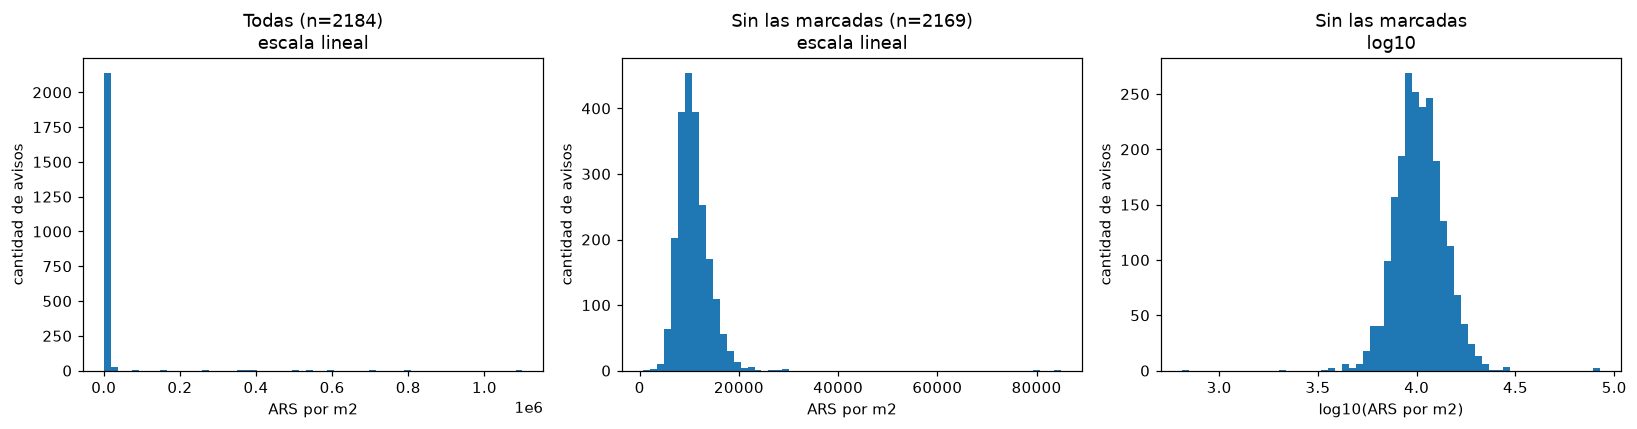

                      n       maximo  asimetria   en log
TODAS              2184    1,100,000      15.14     4.87
SIN LAS MARCADAS   2169       85,000       7.05    -0.12

las filas que se excluyen, y por que:
motivo_sospecha
superficie fuera de rango    42


In [10]:
ars = df[df["moneda"] == "ARS"].copy()

objetivo = ars["precio_m2"].dropna()
objetivo = objetivo[objetivo > 0]

# La misma columna, pero sin las filas que el pipeline ya marco como
# sospechosas. La diferencia entre las dos no es cosmetica: ver mas abajo.
sano = ars.loc[ars["motivo_sospecha"].isna(), "precio_m2"].dropna()
sano = sano[sano > 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(objetivo, bins=60)
axes[0].set_title(f"Todas (n={len(objetivo)})\nescala lineal")
axes[0].set_xlabel("ARS por m2"); axes[0].set_ylabel("cantidad de avisos")

axes[1].hist(sano, bins=60)
axes[1].set_title(f"Sin las marcadas (n={len(sano)})\nescala lineal")
axes[1].set_xlabel("ARS por m2"); axes[1].set_ylabel("cantidad de avisos")

axes[2].hist(np.log10(sano), bins=60)
axes[2].set_title("Sin las marcadas\nlog10")
axes[2].set_xlabel("log10(ARS por m2)"); axes[2].set_ylabel("cantidad de avisos")
plt.tight_layout(); plt.show()

print(f"{'':16} {'n':>6} {'maximo':>12} {'asimetria':>10} {'en log':>8}")
print(f"{'TODAS':16} {len(objetivo):6} {objetivo.max():12,.0f} "
      f"{objetivo.skew():10.2f} {np.log10(objetivo).skew():8.2f}")
print(f"{'SIN LAS MARCADAS':16} {len(sano):6} {sano.max():12,.0f} "
      f"{sano.skew():10.2f} {np.log10(sano).skew():8.2f}")
print()
print("las filas que se excluyen, y por que:")
print(ars.loc[ars["motivo_sospecha"].notna(), "motivo_sospecha"].value_counts().to_string())

**Lo que muestran los tres paneles, y es el punto de esta seccion.**

El primero, con todas las filas, es **ilegible a proposito**: el eje llega a
1.100.000 ARS/m2 y el 99 % de los avisos cae aplastado contra el cero. Esa
es la pinta de una columna con outliers extremos, y es lo que hay que
reconocer antes de calcular cualquier promedio.

Pero esos extremos **no son el mercado**. Los ocho valores mas altos son
avisos con `superficie_cubierta_m2 = 1`, todos ya identificados por el
pipeline en `motivo_sospecha`: alguien publico un departamento cargando 1 m2
en el campo de la superficie, y al dividir el precio por 1 el `precio_m2`
explota. No es un alquiler caro, es una division por un dato mal cargado.

En los avisos en pesos hay **42 marcados** por superficie fuera de rango, y
**15 de ellos** tenian un `precio_m2` calculado (el resto no llega a tener
precio o superficie). Sacando esos 15, el conteo pasa de 2184 a 2169 y la
lectura cambia por completo:

| | Todas | Sin las marcadas |
|---|---|---|
| Maximo | 1.100.000 | **85.000** |
| Asimetria | 15,14 | **7,05** |
| Asimetria en log10 | 4,87 | **-0,12** |

**El `log10(precio_m2)` queda practicamente simetrico (-0,12).** Es el
resultado mas util de esta seccion para la Entrega 3: el objetivo, en
logaritmo y sin las filas defectuosas, tiene forma de campana, con mediana
en 10.200 ARS/m2 y el 99 % de los avisos por debajo de 20.000.

Dicho de otra forma: **no hay una clase que se coma todo**, que era lo que
la consigna pedia verificar. Lo que habia era un puñado de errores de carga
haciendose pasar por cola larga.

### 1.7 Asimetria de las numericas: cuales tienen cola larga

In [11]:
skew = df.select_dtypes("number").skew().sort_values(ascending=False)
print(skew.round(2).to_string())

superficie_cubierta_m2    49.36
superficie_total_m2       48.73
precio_m2                 15.75
dist_centro_km            12.44
antiguedad                 9.83
longitud                   8.03
plantas                    6.89
banos                      4.23
valor_expensas             3.26
prp_id                     3.03
dormitorios                1.48
densidad_1km               1.06
usr_id                     1.03
ambientes                  0.42
precio                     0.37
dias_publicado             0.17
veces_visto               -0.02
zona_geo                  -0.26
latitud                  -11.33


---
## 2. Valores extremos: mirarlos, no esconderlos

El pipeline **marca** las filas sospechosas en `motivo_sospecha` en vez de
borrarlas. La unidad de analisis es el aviso tal como se publico, y un aviso
mal cargado es un aviso que existe.

In [12]:
if "motivo_sospecha" in df:
    print(df["motivo_sospecha"].value_counts(dropna=False).to_string())
    print()
    print("Ejemplo del extremo de precio_m2:")
    cols = [c for c in ["clave","precio","moneda","superficie_cubierta_m2","precio_m2","motivo_sospecha"] if c in df]
    print(df.nsmallest(3, "precio_m2")[cols].to_string(index=False))

motivo_sospecha
NaN                                       2439
superficie fuera de rango                   52
precio parece de venta, no de alquiler      13

Ejemplo del extremo de precio_m2:
              clave  precio moneda  superficie_cubierta_m2  precio_m2           motivo_sospecha
     inmoup:49219-3   700.0    USD                150000.0   0.004667 superficie fuera de rango
   inmoup:10325-453  1200.0    USD                   400.0   3.000000                       NaN
inmoclick:10325-330  1200.0    USD                   400.0   3.000000                       NaN


**La marca no es decorativa, y se puede demostrar.** Si `motivo_sospecha`
identifica de verdad los errores de carga, sacarlas tiene que cambiar la
forma de la distribucion de superficie. Se mide:

con superficie: 2438  |  positivas: 2405  |  en cero: 33

TODAS          n= 2405  min=     1.0  max= 150000.0  asimetria=  49.02
SIN MARCADAS   n= 2373  min=    10.0  max=    850.0  asimetria=   6.77


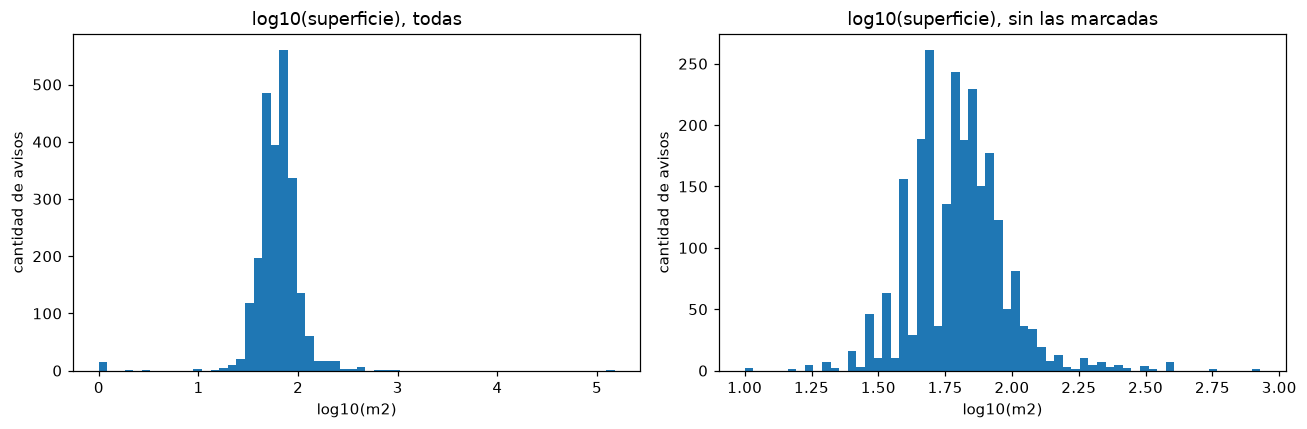

In [13]:
s = df["superficie_cubierta_m2"].dropna()
pos = s[s > 0]
limpia_sup = df.loc[df["motivo_sospecha"].isna(), "superficie_cubierta_m2"].dropna()
limpia_sup = limpia_sup[limpia_sup > 0]

print(f"con superficie: {len(s)}  |  positivas: {len(pos)}  |  en cero: {int((s==0).sum())}")
print()
print(f"TODAS          n={len(pos):5}  min={pos.min():8.1f}  max={pos.max():9.1f}  asimetria={pos.skew():7.2f}")
print(f"SIN MARCADAS   n={len(limpia_sup):5}  min={limpia_sup.min():8.1f}  max={limpia_sup.max():9.1f}  asimetria={limpia_sup.skew():7.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(np.log10(pos), bins=60)
ax1.set_title("log10(superficie), todas")
ax1.set_xlabel("log10(m2)"); ax1.set_ylabel("cantidad de avisos")
ax2.hist(np.log10(limpia_sup), bins=60)
ax2.set_title("log10(superficie), sin las marcadas")
ax2.set_xlabel("log10(m2)"); ax2.set_ylabel("cantidad de avisos")
plt.tight_layout(); plt.show()

La asimetria de `superficie_cubierta_m2` cae de **~49 a ~6,8** al excluir las
filas marcadas, y el rango pasa de 1-150.000 m2 a 10-850 m2, que ya es un
rango de departamentos reales. Los 33 avisos con superficie **en cero** son
un caso aparte: no son un valor chico, son el campo sin cargar, y se tratan
como nulos (ademas, no tienen logaritmo).

---
## 3. Geografia: de dos numeros crudos a features con sentido

`latitud` y `longitud` solas no le dicen nada a un modelo: -32,89 no es "mas"
ni "menos" que -32,90 en ninguna escala util. El pipeline las convierte en
`dist_centro_km`, `zona_geo`, `densidad_1km` y `tiene_geo`.

In [14]:
geo = [c for c in ["tiene_geo","dist_centro_km","zona_geo","densidad_1km"] if c in df]
if not geo:
    print("Este CSV todavia no tiene las features geograficas.")
else:
    print("cobertura de coordenadas:", f"{df['tiene_geo'].mean():.1%}")
    print()
    print(df[["dist_centro_km","densidad_1km"]].describe().round(2))
    print()
    print("avisos por zona_geo:")
    print(df["zona_geo"].value_counts(dropna=False).sort_index().to_string())

cobertura de coordenadas: 93.7%

       dist_centro_km  densidad_1km
count         2345.00       2345.00
mean             5.14        128.09
std             10.34        117.50
min              0.02          0.00
25%              1.46         36.00
50%              2.94         84.00
75%              5.70        173.00
max            255.43        408.00

avisos por zona_geo:
zona_geo
-1.0     30
 0.0    463
 1.0    138
 2.0    274
 3.0    983
 4.0    146
 5.0    311
 NaN    159


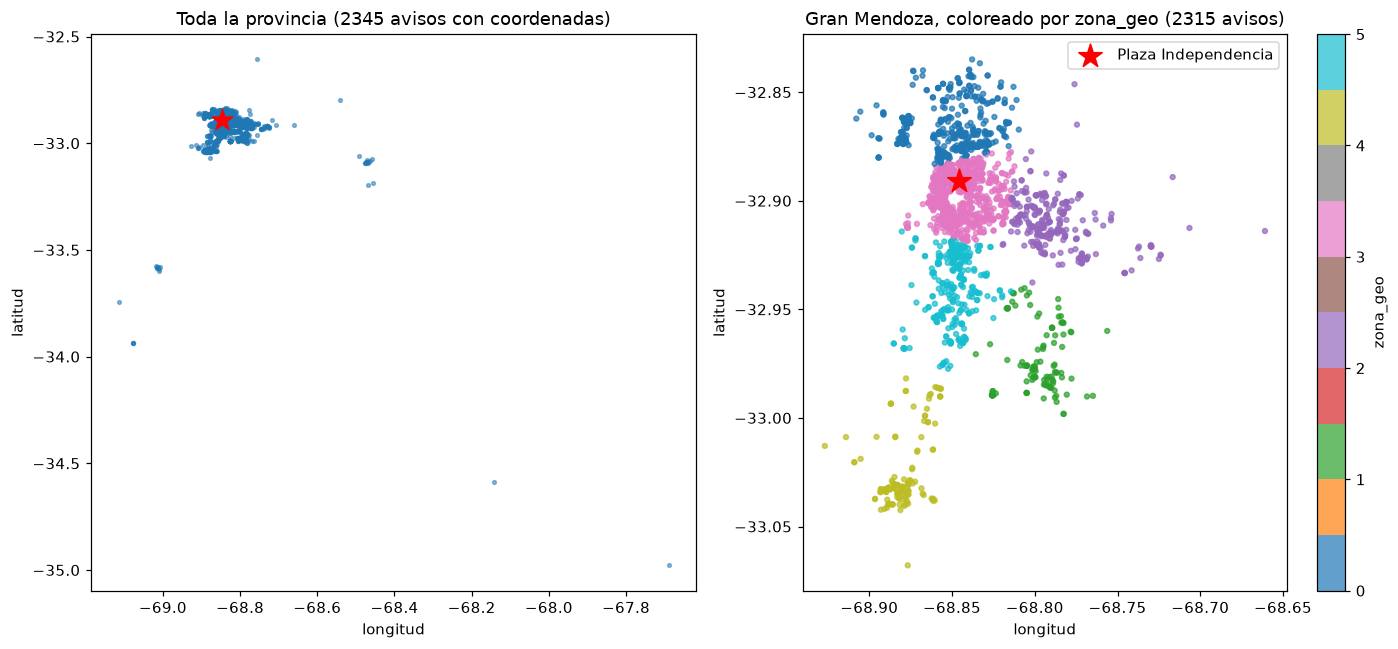

avisos a mas de 30 km del centro: 30
son los que zona_geo agrupa como -1 (interior provincial)


In [15]:
if "dist_centro_km" in df:
    con_geo = df[df["tiene_geo"]]
    # Dos paneles: el de la izquierda muestra toda la provincia y explica por
    # que zona_geo necesita separar el interior; el de la derecha hace zoom
    # al aglomerado, que es donde vive el 99 % de los avisos. Con un solo
    # panel, los cuatro puntos del sur estiran la escala y el Gran Mendoza
    # queda reducido a una mancha.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

    ax1.scatter(con_geo["longitud"], con_geo["latitud"], s=6, alpha=0.5)
    ax1.scatter([-68.8458], [-32.8908], marker="*", s=200, c="red")
    ax1.set_title(f"Toda la provincia ({len(con_geo)} avisos con coordenadas)")
    ax1.set_xlabel("longitud"); ax1.set_ylabel("latitud")

    agl = con_geo[con_geo["dist_centro_km"] <= 30]
    sc = ax2.scatter(agl["longitud"], agl["latitud"], c=agl["zona_geo"],
                     s=10, alpha=0.7, cmap="tab10")
    ax2.scatter([-68.8458], [-32.8908], marker="*", s=260, c="red",
                label="Plaza Independencia")
    ax2.set_title(f"Gran Mendoza, coloreado por zona_geo ({len(agl)} avisos)")
    ax2.set_xlabel("longitud"); ax2.set_ylabel("latitud")
    ax2.legend(); plt.colorbar(sc, ax=ax2, label="zona_geo")
    plt.tight_layout(); plt.show()

    print(f"avisos a mas de 30 km del centro: {int((con_geo['dist_centro_km'] > 30).sum())}")
    print("son los que zona_geo agrupa como -1 (interior provincial)")

---
## 4. Las cuatro hipotesis

Cada ficha tiene los **seis campos del TP2**, en ese orden y con esos
titulos. La zona sale del semaforo de la catedra, aplicado sobre el **valor
absoluto** de la medida que corresponde a la plantilla:

| Medida | Cuando se usa | Rojo | Amarillo | Verde |
|---|---|---|---|---|
| Separacion estandarizada | una numerica entre **dos** grupos | < 0,2 | 0,2 a 0,8 | > 0,8 |
| eta cuadrado | una numerica entre **muchos** grupos | < 0,05 | 0,05 a 0,25 | > 0,25 |
| Correlacion | **dos** numericas | < 0,2 | 0,2 a 0,6 | > 0,6 |
| Brecha Spearman - Pearson | detectar que la relacion **no es recta** | < 0,05 | 0,05 a 0,15 | > 0,15 |

Las cuatro salen de las dos preguntas: **H1 y H3 responden** algo sobre el
mercado de alquileres; **H2 y H4 deciden** sobre una columna del modelo.

Todas se calculan sobre las filas **sin marca en `motivo_sospecha`**: los
avisos con superficie de 1 m2 o precio de venta no son el mercado, y
dejarlos adentro mueve las medidas sin decir nada sobre el dominio.

In [16]:
# Las medidas del semaforo, una por plantilla. Se definen una sola vez para
# que las cuatro fichas usen exactamente el mismo criterio.

def separacion_estandarizada(a, b):
    """Diferencia de medias en unidades de desvio (d de Cohen)."""
    a, b = a.dropna(), b.dropna()
    s = np.sqrt(((len(a)-1)*a.var() + (len(b)-1)*b.var()) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / s

def eta_cuadrado(grupo, y):
    """Proporcion de la varianza de y que explica la pertenencia al grupo."""
    d = pd.DataFrame({"g": grupo, "y": y}).dropna()
    media = d.y.mean()
    entre = sum(len(x) * (x.y.mean() - media)**2 for _, x in d.groupby("g"))
    return entre / ((d.y - media)**2).sum()

CORTES = {
    "separacion estandarizada": (0.2, 0.8),
    "eta cuadrado":             (0.05, 0.25),
    "correlacion":              (0.2, 0.6),
    "brecha spearman-pearson":  (0.05, 0.15),
}

def zona(medida, valor):
    """Zona del semaforo. Los cortes se aplican sobre el valor absoluto:
    el signo dice la direccion y se lee aparte."""
    rojo, verde = CORTES[medida]
    v = abs(valor)
    return "ROJO" if v < rojo else ("VERDE" if v > verde else "AMARILLO")

# El analisis se hace sobre los avisos sin marca de calidad.
limpio = df[df["motivo_sospecha"].isna()]
ars = limpio[limpio["moneda"] == "ARS"]
print("filas totales:", len(df))
print("sin marca en motivo_sospecha:", len(limpio))
print("de esas, en pesos:", len(ars))

filas totales: 2504
sin marca en motivo_sospecha: 2439
de esas, en pesos: 2232


### H1 - La moneda parte el mercado en dos poblaciones

*Pregunta: **responder** (sobre el dominio). Plantilla: **comparacion**.*

**1. La afirmacion.** El `precio_m2` de los avisos publicados en ARS y el de
los publicados en USD no pertenecen a la misma poblacion: son dos escalas
distintas conviviendo en una sola columna.

**2. Que espero ver.** Que la diferencia sea grande, porque un alquiler en
dolares y uno en pesos no se publican con los mismos numeros. Espero
separacion estandarizada por encima de 0,8 (verde), aunque no se cuanto: si
los avisos en USD fueran solo propiedades premium publicadas en otra moneda,
podria quedar en amarillo.

**3. Como la mido.** Plantilla de comparacion, una numerica (`precio_m2`)
entre dos grupos (`moneda`), asi que la medida es la **separacion
estandarizada** y el grafico es un boxplot por grupo. Va en escala
logaritmica porque en escala lineal el grupo en USD queda aplastado contra
el cero y el grafico no se puede leer.

n en ARS: 2169  |  n en USD: 198
mediana ARS: 10,200  |  mediana USD: 10.23

separacion estandarizada = 3.019  ->  VERDE


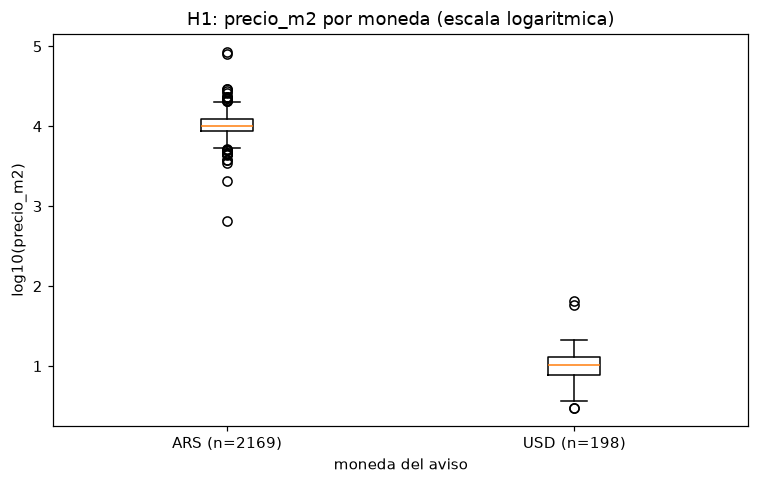

In [17]:
a = ars["precio_m2"]
b = limpio.loc[limpio["moneda"] == "USD", "precio_m2"]
d = separacion_estandarizada(a, b)

print(f"n en ARS: {a.notna().sum()}  |  n en USD: {b.notna().sum()}")
print(f"mediana ARS: {a.median():,.0f}  |  mediana USD: {b.median():,.2f}")
print()
print(f"separacion estandarizada = {d:.3f}  ->  {zona('separacion estandarizada', d)}")

fig, ax = plt.subplots(figsize=(7, 4.5))
datos = [np.log10(x.dropna()[x.dropna() > 0]) for x in (a, b)]
ax.boxplot(datos, tick_labels=[f"ARS (n={a.notna().sum()})",
                               f"USD (n={b.notna().sum()})"])
ax.set_ylabel("log10(precio_m2)")
ax.set_xlabel("moneda del aviso")
ax.set_title("H1: precio_m2 por moneda (escala logaritmica)")
plt.tight_layout(); plt.show()

**4. Que encontre.** Separacion estandarizada **3,02**, muy por encima del
corte de 0,8: **zona VERDE**. El boxplot muestra dos cajas que no se tocan,
separadas por unos tres ordenes de magnitud (las medianas son ~10.300 y
~10,8).

**5. Que movimiento hice.** Ninguno. El verde cierra la hipotesis: los
movimientos solo se habilitan en amarillo.

**6. Que hago con eso.** **El modelo se entrena solo sobre los avisos en
ARS.** Mezclar las dos monedas en una misma regresion de `precio_m2` es
sumar pesos y dolares en la misma variable.

La alternativa era convertir con una cotizacion fija, que conserva las
filas en USD pero mete un supuesto de tipo de cambio que este dataset no
permite justificar: no sabemos a que cotizacion pensaba cada anunciante.
Los avisos en USD quedan como analisis aparte para la Entrega 3.

### H2 - La relacion entre superficie y precio no es recta

*Pregunta: **predecir** (decide sobre una columna del modelo). Plantilla:
**asociacion**.*

**1. La afirmacion.** La relacion entre `superficie_cubierta_m2` y `precio`
no es lineal, asi que la superficie no puede entrar al modelo en su escala
original.

**2. Que espero ver.** Que un departamento del doble de superficie no cueste
exactamente el doble: espero rendimientos decrecientes, con la nube curvada
hacia abajo. Si es asi, Spearman deberia superar a Pearson y la brecha caer
en amarillo. Tambien es posible que la relacion sea bastante recta en este
rango de superficies y la brecha quede en rojo.

**3. Como la mido.** Plantilla de asociacion entre dos numericas, y lo que
se discute es la **forma** de la relacion, no su fuerza: la medida es la
**brecha Spearman - Pearson** y el grafico es la nube de puntos, primero en
escala original y despues en la escala transformada.

n = 2169
Pearson  = 0.556
Spearman = 0.663
brecha   = 0.107  ->  AMARILLO


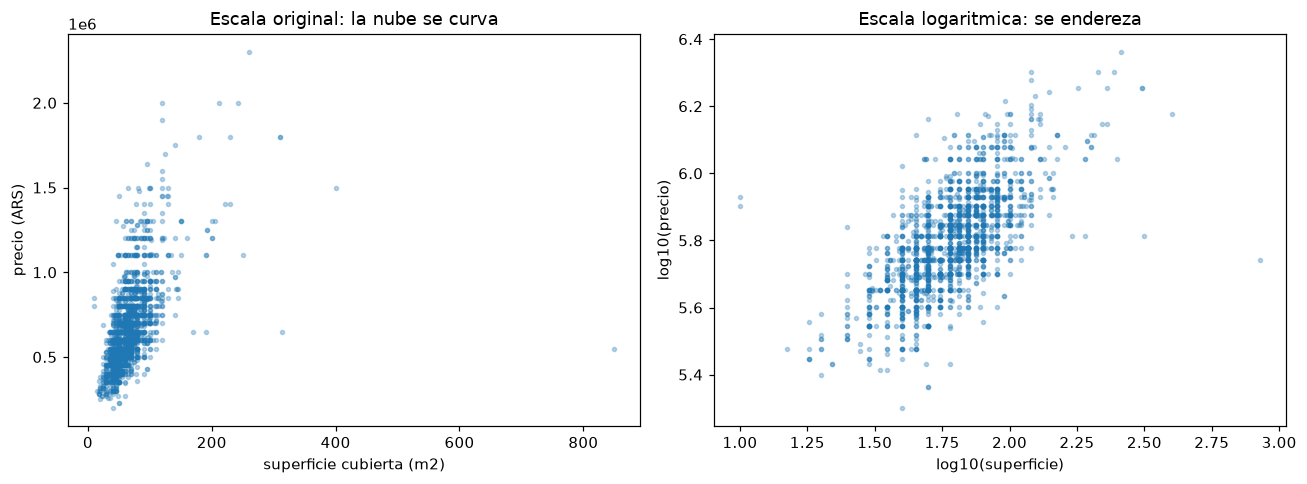

In [18]:
sup = ars[["superficie_cubierta_m2", "precio"]].dropna()
sup = sup[sup["superficie_cubierta_m2"] > 0]

pe = sup["superficie_cubierta_m2"].corr(sup["precio"])
sp = sup["superficie_cubierta_m2"].corr(sup["precio"], method="spearman")
brecha = abs(sp) - abs(pe)

print(f"n = {len(sup)}")
print(f"Pearson  = {pe:.3f}")
print(f"Spearman = {sp:.3f}")
print(f"brecha   = {brecha:.3f}  ->  {zona('brecha spearman-pearson', brecha)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.scatter(sup["superficie_cubierta_m2"], sup["precio"], s=7, alpha=0.3)
ax1.set_xlabel("superficie cubierta (m2)"); ax1.set_ylabel("precio (ARS)")
ax1.set_title("Escala original: la nube se curva")

ax2.scatter(np.log10(sup["superficie_cubierta_m2"]), np.log10(sup["precio"]),
            s=7, alpha=0.3)
ax2.set_xlabel("log10(superficie)"); ax2.set_ylabel("log10(precio)")
ax2.set_title("Escala logaritmica: se endereza")
plt.tight_layout(); plt.show()

**4. Que encontre.** Pearson **0,556** contra Spearman **0,663**: brecha
**0,107**, entre 0,05 y 0,15, o sea **zona AMARILLA**. El grafico de la
izquierda muestra por que: la nube sube de forma ordenada pero curva, con
los precios creciendo cada vez menos a medida que aumenta la superficie.
Spearman, que solo mira el orden, captura esa relacion; Pearson, que exige
una recta, la subestima.

In [19]:
# Movimiento: cambiar la escala. Se vuelve a medir sobre log-log.
ls = np.log10(sup["superficie_cubierta_m2"])
lp = np.log10(sup["precio"])
pe2, sp2 = ls.corr(lp), ls.corr(lp, method="spearman")
brecha2 = abs(sp2) - abs(pe2)

print("despues del movimiento (log-log):")
print(f"  Pearson  = {pe2:.3f}   (antes {pe:.3f})")
print(f"  Spearman = {sp2:.3f}   (antes {sp:.3f})")
print(f"  brecha   = {brecha2:.3f}  ->  {zona('brecha spearman-pearson', brecha2)}")
print()
print(f"la correlacion como fuerza pasa de {zona('correlacion', pe)}"
      f" a {zona('correlacion', pe2)}")

despues del movimiento (log-log):
  Pearson  = 0.668   (antes 0.556)
  Spearman = 0.663   (antes 0.663)
  brecha   = -0.005  ->  ROJO

la correlacion como fuerza pasa de AMARILLO a VERDE


**5. Que movimiento hice.** **Cambiar la escala** (uno solo, de los dos que
habilita el amarillo). Lo eligio el grafico: la nube de la izquierda sube de
forma ordenada pero curva, que es exactamente el caso en que el TP2 indica
este movimiento y no los otros dos. No hay grupos separados que justifiquen
partir la poblacion, ni una tercera variable que empuje a las dos a la vez.

Sobre log-log la brecha cae a **-0,005**: la curvatura desaparece. Y como
efecto lateral, la correlacion de Pearson sube de **0,556 a 0,668**, o sea
de amarillo a verde: en la escala correcta, la superficie explica el precio
bastante mejor de lo que parecia.

**6. Que hago con eso.** **`superficie_cubierta_m2` entra al modelo como
`log10(superficie)`, y `precio_m2` se modela tambien en logaritmo.** No es
una mejora cosmetica: en la escala original, una regresion lineal subestima
sistematicamente los departamentos chicos y sobreestima los grandes.

Ademas, esto vuelve obligatorio tratar los **ceros** de superficie como
nulos y no como un valor chico: el logaritmo de cero no existe. El pipeline
ya los deja fuera de `precio_m2`, y las superficies imposibles (1 m2) estan
marcadas en `motivo_sospecha`.

### H3 - El precio por m2 baja con la distancia al centro

*Pregunta: **responder** (sobre el dominio). Plantilla: **asociacion**.*

**1. La afirmacion.** A mayor `dist_centro_km`, menor `precio_m2`: los
departamentos mas lejos de Plaza Independencia se alquilan mas baratos por
metro cuadrado.

**2. Que espero ver.** Una correlacion negativa y clara, porque es el
comportamiento clasico de cualquier mercado inmobiliario urbano. Espero
verde o al menos amarillo. Si diera rojo seria porque el Gran Mendoza es
geograficamente chico y la distancia al centro no alcanza para distinguir
barrios.

**3. Como la mido.** Plantilla de asociacion entre dos numericas, y lo que
se discute es la **fuerza** de la relacion: la medida es la **correlacion**
y el grafico es la nube de puntos con la mediana por anillo de distancia
superpuesta.

n = 2025
Pearson  = -0.040  ->  ROJO
Spearman = -0.087  ->  ROJO

mediana de precio_m2 por anillo de distancia:
                count   median
dist_centro_km                
(0, 1]            334  10306.0
(1, 2]            341  11250.0
(2, 3]            346  10652.0
(3, 5]            419  10000.0
(5, 10]           350   9938.0
(10, 30]          213  11184.0
(30, 300]          22   9251.0


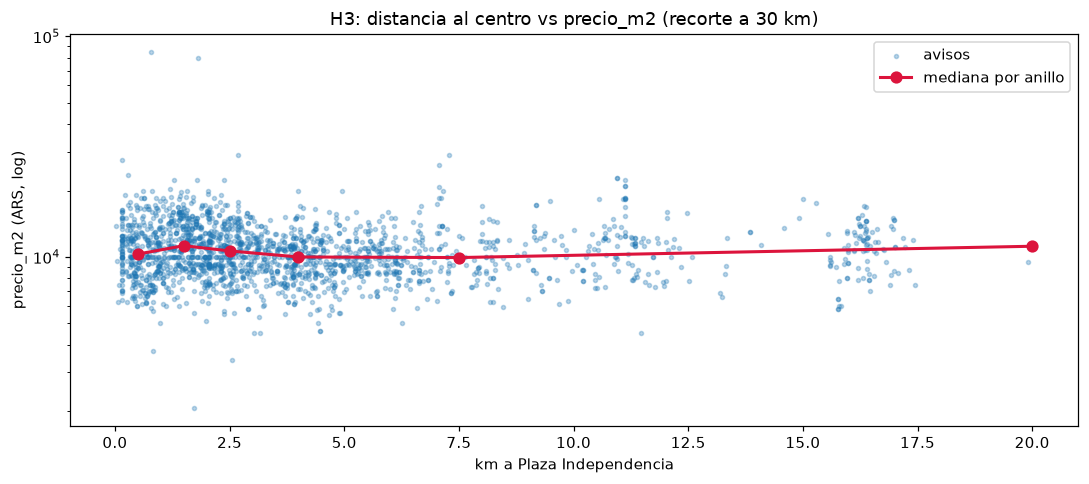


recortado a 30 km para que se lea: quedan fuera 22 avisos del interior


In [20]:
h3 = ars[["dist_centro_km", "precio_m2"]].dropna()
pe3 = h3["dist_centro_km"].corr(h3["precio_m2"])
sp3 = h3["dist_centro_km"].corr(h3["precio_m2"], method="spearman")

print(f"n = {len(h3)}")
print(f"Pearson  = {pe3:.3f}  ->  {zona('correlacion', pe3)}")
print(f"Spearman = {sp3:.3f}  ->  {zona('correlacion', sp3)}")
print()
print("mediana de precio_m2 por anillo de distancia:")
anillos = pd.cut(h3["dist_centro_km"], [0, 1, 2, 3, 5, 10, 30, 300])
print(h3.groupby(anillos, observed=True)["precio_m2"]
        .agg(["count", "median"]).round(0).to_string())

agl = h3[h3["dist_centro_km"] <= 30]
med = agl.groupby(pd.cut(agl["dist_centro_km"], [0,1,2,3,5,10,30]),
                  observed=True)["precio_m2"].median()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(agl["dist_centro_km"], agl["precio_m2"], s=7, alpha=0.3, label="avisos")
ax.plot([i.mid for i in med.index], med.values, "o-", c="crimson", lw=2, ms=7,
        label="mediana por anillo")
ax.set_yscale("log")
ax.set_xlabel("km a Plaza Independencia"); ax.set_ylabel("precio_m2 (ARS, log)")
ax.set_title("H3: distancia al centro vs precio_m2 (recorte a 30 km)")
ax.legend()
plt.tight_layout(); plt.show()
print(f"\nrecortado a 30 km para que se lea: quedan fuera {len(h3)-len(agl)} avisos del interior")

**4. Que encontre.** Correlacion de Spearman **-0,087** (Pearson -0,040).
En valor absoluto esta por debajo de 0,2: **zona ROJA**. El grafico lo
confirma: la linea de medianas es **plana** a lo largo de los 20 km del
aglomerado, y el anillo mas lejano tiene una mediana apenas mas alta que el
mas cercano, que es lo contrario de lo que afirmaba la hipotesis.

**5. Que movimiento hice.** Ninguno. El rojo cierra la hipotesis: los
movimientos solo se habilitan en amarillo. Partir la poblacion hasta que
aparezca el efecto es justamente lo que el TP2 advierte que no hay que
hacer.

**6. Que hago con eso. REFUTADA.** `dist_centro_km` **no entra al modelo
como variable explicativa del precio**: no aporta informacion sobre el
`precio_m2` en este mercado. Se conserva en el dataset porque es barata de
calcular y puede servir combinada con otras variables en la Entrega 3, pero
no se la trata como predictor por si sola.

La lectura del dominio es que el Gran Mendoza mide unos 20 km de punta a
punta y dentro de Capital conviven barrios muy distintos: "kilometros al
centro" mezcla realidades que el precio distingue. Lo que no sabemos
todavia es si **otra** forma de codificar la ubicacion si explicaria el
precio. Eso esta en la seccion 6.

### H4 - `ambientes` y `dormitorios` miden lo mismo

*Pregunta: **predecir** (decide sobre una columna del modelo). Plantilla:
**asociacion**.*

**1. La afirmacion.** `ambientes` y `dormitorios` estan tan asociadas que
darle las dos al modelo es darle la misma informacion dos veces.

**2. Que espero ver.** Una correlacion alta, porque las dos cuentan
habitaciones, pero no perfecta: un monoambiente y un dos ambientes con un
dormitorio tienen el mismo numero de dormitorios y distinto numero de
ambientes. Espero verde, en el rango de 0,7 a 0,9.

**3. Como la mido.** Plantilla de asociacion entre dos numericas, discutiendo
la fuerza: la medida es la **correlacion** y el grafico es la tabla cruzada
de las dos columnas, que muestra donde se separan.

n con las dos columnas = 1389
Pearson  = 0.622  ->  VERDE
Spearman = 0.640  ->  VERDE

nulos:
  ambientes   42.8%
  dormitorios 2.2%


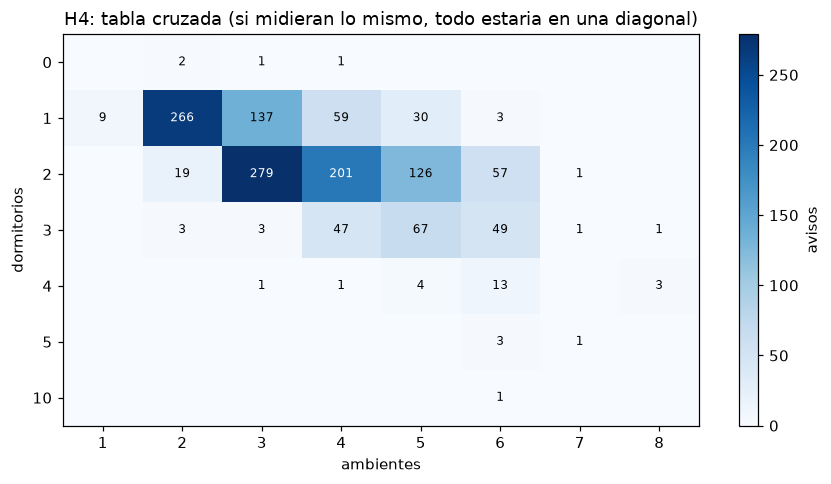

In [21]:
par = limpio[["ambientes", "dormitorios"]].dropna()
pe4 = par["ambientes"].corr(par["dormitorios"])
sp4 = par["ambientes"].corr(par["dormitorios"], method="spearman")

print(f"n con las dos columnas = {len(par)}")
print(f"Pearson  = {pe4:.3f}  ->  {zona('correlacion', pe4)}")
print(f"Spearman = {sp4:.3f}  ->  {zona('correlacion', sp4)}")
print()
print("nulos:")
print(f"  ambientes   {limpio['ambientes'].isna().mean():.1%}")
print(f"  dormitorios {limpio['dormitorios'].isna().mean():.1%}")

cruz = pd.crosstab(limpio["dormitorios"], limpio["ambientes"])
fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(cruz.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(cruz.columns)), [int(c) for c in cruz.columns])
ax.set_yticks(range(len(cruz.index)), [int(i) for i in cruz.index])
ax.set_xlabel("ambientes"); ax.set_ylabel("dormitorios")
ax.set_title("H4: tabla cruzada (si midieran lo mismo, todo estaria en una diagonal)")
for i in range(len(cruz.index)):
    for j in range(len(cruz.columns)):
        v = cruz.values[i, j]
        if v: ax.text(j, i, v, ha="center", va="center", fontsize=8,
                      color="white" if v > cruz.values.max()/2 else "black")
plt.colorbar(im, ax=ax, label="avisos")
plt.tight_layout(); plt.show()

**4. Que encontre.** Correlacion de Pearson **0,622**, apenas por encima del
corte de 0,6: **zona VERDE**, pero al borde. La tabla cruzada muestra que la
masa no cae en una sola diagonal sino en dos: con un dormitorio hay avisos
de 2, 3 y hasta 4 ambientes.

Conviene decir el numero con esa precision. **0,622 es verde por 0,022**, y
si el dataset cambia un poco puede cruzar a amarillo. No es una asociacion
tan fuerte como para tratarlas como la misma columna sin mirar.

**5. Que movimiento hice.** Ninguno: el verde cierra la hipotesis.

**6. Que hago con eso.** **Entra `dormitorios`, sale `ambientes`.** La
hipotesis se confirma, pero el motivo que termina decidiendo no es el que
esperaba: aun si estuvieran menos asociadas, `ambientes` tiene **43,0 % de
nulos** contra **2,2 %** de `dormitorios`. Darle al modelo una columna que
falta en cuatro de cada diez filas, para ganar la poca informacion que
agrega sobre la otra, no compensa.

Si mas adelante hiciera falta la distincion entre monoambiente y dos
ambientes, la via no es recuperar `ambientes` sino derivar un indicador
binario desde `superficie_cubierta_m2` y `dormitorios`.

---
## 5. La tabla de columnas candidatas

El entregable que se lleva la Entrega 3. **La ultima columna es el chequeo
de fuga**, y es la que mas caro se paga si falta: antes de darle una columna
al modelo hay que preguntarse si esa columna existiria **en el momento de
predecir**.

La tabla se arma desde un diccionario y no a mano, para poder verificar que
**ninguna columna del dataset quede sin decision**. Si el pipeline agrega
una columna nueva, la verificacion de abajo la delata.

In [22]:
# columna -> (que mide, zona, decision, existiria al predecir)
DECISIONES = {
    # --- las que entran ---
    "superficie_cubierta_m2": ("m2 cubiertos", "amarilla", "Entra en log10 (H2)", "Si - la publica el aviso"),
    "superficie_total_m2":    ("m2 totales", "verde", "Entra en log10", "Si"),
    "dormitorios":            ("Cantidad de dormitorios", "verde", "Entra (H4)", "Si"),
    "banos":                  ("Cantidad de banos", "verde", "Entra", "Si"),
    "moneda":                 ("Moneda del aviso", "verde", "Segmenta: se modela ARS (H1)", "Si"),
    "fuente":                 ("Portal de origen", "verde", "Entra", "Si"),
    "localidad":              ("Departamento de Mendoza", "verde", "Entra, aunque aporta poco", "Si"),
    "tipo_anunciante":        ("Inmobiliaria o dueno directo", "verde", "Entra", "Si"),
    "estado_conservacion":    ("Bueno / a refaccionar / ...", "verde", "Entra", "Si"),
    "tiene_geo":              ("Si el aviso trae coordenadas", "verde", "Entra: marca el faltante", "Si"),
    "cochera":                ("Con o sin cochera", "amarilla", "Entra, hay que normalizar el texto", "Si"),
    "antiguedad":             ("Anos de la propiedad", "amarilla", "Entra con marca de faltante", "Si"),
    "acepta_mascotas":        ("Acepta mascotas", "amarilla", "Entra como tres estados", "Si"),
    "tiene_expensas":         ("Si paga expensas", "amarilla", "Entra como tres estados", "Si"),
    "valor_expensas":         ("Monto de expensas", "amarilla", "Entra; nulo estructural sin expensas", "Si"),
    "fecha_scraping":         ("Corrida que observo el aviso", "amarilla", "Entra como control temporal", "Si"),
    "dist_centro_km":         ("Distancia a Plaza Independencia", "roja", "No como explicativa (H3)", "Si"),
    "zona_geo":               ("Cluster geografico", "roja", "No: eta2 = 0,029 (seccion 6)", "Si"),
    "densidad_1km":           ("Vecinos en 1 km", "amarilla", "A evaluar en Entrega 3", "Si"),

    # --- las que salen ---
    "precio":                 ("Precio publicado", "roja", "SALE: es el objetivo x superficie", "NO - es lo que se quiere evaluar"),
    "precio_m2":              ("Precio por m2", "-", "Es la COLUMNA OBJETIVO", "-"),
    "ambientes":              ("Cantidad de ambientes", "roja", "Sale: 43% nulo, se queda dormitorios (H4)", "Si"),
    "amoblado":               ("Amoblado", "roja", "Sale: mas de la mitad sin dato", "Si"),
    "tipo_construccion":      ("Departamento, PH, ...", "roja", "Sale: 56% nulo", "Si"),
    "piscina":                ("Tiene piscina", "roja", "Sale: 61% nulo", "Si"),
    "plantas":                ("Cantidad de plantas", "roja", "Sale: 63% nulo", "Si"),
    "zona_escolar":           ("Zona escolar declarada", "roja", "Sale: 73% nulo", "Si"),
    "fecha_publicacion":      ("Cuando se publico", "roja", "Sale: nulo estructural en Inmoclick", "Si"),
    "latitud":                ("Coordenada", "roja", "Sale: entra via dist_centro_km", "Si"),
    "longitud":               ("Coordenada", "roja", "Sale: entra via dist_centro_km", "Si"),
    "direccion":              ("Direccion publicada", "roja", "Sale: casi unica por fila", "Si"),
    "descripcion":            ("Texto libre", "roja", "Sale de esta entrega (NLP)", "Si"),
    "publicador":             ("Quien publica", "roja", "Sale: cientos de categorias", "Si"),
    "condicion":              ("Alquiler", "roja", "Sale: constante", "Si"),
    "provincia":              ("Mendoza", "roja", "Sale: constante", "Si"),
    "es_dueno_directo":       ("Idem tipo_anunciante", "roja", "Sale: duplica tipo_anunciante", "Si"),
    "id_publicado":           ("ID que muestra la ficha", "roja", "Sale: identificador", "Si"),
    "clave":                  ("Clave primaria", "roja", "Sale: identificador", "Si"),
    "url":                    ("URL del aviso", "roja", "Sale: identificador", "Si"),
    "usr_id":                 ("ID de la inmobiliaria", "roja", "Sale: identificador", "Si"),
    "prp_id":                 ("ID del aviso en el portal", "roja", "Sale: identificador", "Si"),

    # --- las censuradas por la ventana de observacion ---
    "dias_publicado":         ("Dias entre primera y ultima vista", "roja", "Sale por ahora: ventana de 15 dias", "NO para un aviso nuevo: vale 0"),
    "veces_visto":            ("Corridas en que aparecio", "roja", "Sale por ahora: ventana de 15 dias", "NO para un aviso nuevo: vale 1"),
    "primera_vista":          ("Primera corrida que lo vio", "roja", "Sale: censurada por la ventana", "NO"),
    "ultima_vista":           ("Ultima corrida que lo vio", "roja", "Sale: censurada por la ventana", "NO"),

    # --- marcas de calidad: filtran filas, no son features ---
    "motivo_sospecha":        ("Marca de valor sospechoso", "-", "No es feature: filtra filas", "-"),
    "posible_duplicado_cruzado": ("Mismo inmueble en dos portales", "-", "No es feature: filtra filas", "-"),
}

tabla = pd.DataFrame(
    [(c, *v) for c, v in DECISIONES.items()],
    columns=["columna", "que mide", "zona", "decision", "existiria al predecir?"],
)

# Verificacion: ninguna columna del dataset puede quedar sin decision.
faltan = set(df.columns) - set(DECISIONES)
sobran = set(DECISIONES) - set(df.columns)
print("columnas del dataset:", len(df.columns), "| con decision:", len(DECISIONES))
print("sin decision:", sorted(faltan) if faltan else "ninguna")
print("en la tabla pero no en el dataset:", sorted(sobran) if sobran else "ninguna")
print()
print("reparto por zona:")
print(tabla["zona"].value_counts().to_string())

columnas del dataset: 47 | con decision: 47
sin decision: ninguna
en la tabla pero no en el dataset: ninguna

reparto por zona:
zona
roja        27
verde        9
amarilla     8
-            3


In [23]:
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_colwidth", 44)
tabla.sort_values(["zona", "columna"])

,columna,que mide,zona,decision,existiria al predecir?
45,motivo_sospecha,Marca de valor sospechoso,-,No es feature: filtra filas,-
46,posible_duplicado_cruzado,Mismo inmueble en dos portales,-,No es feature: filtra filas,-
20,precio_m2,Precio por m2,-,Es la COLUMNA OBJETIVO,-
12,acepta_mascotas,Acepta mascotas,amarilla,Entra como tres estados,Si
11,antiguedad,Anos de la propiedad,amarilla,Entra con marca de faltante,Si
10,cochera,Con o sin cochera,amarilla,"Entra, hay que normalizar el texto",Si
18,densidad_1km,Vecinos en 1 km,amarilla,A evaluar en Entrega 3,Si
15,fecha_scraping,Corrida que observo el aviso,amarilla,Entra como control temporal,Si
0,superficie_cubierta_m2,m2 cubiertos,amarilla,Entra en log10 (H2),Si - la publica el aviso
13,tiene_expensas,Si paga expensas,amarilla,Entra como tres estados,Si


**Las dos fugas del dataset.** La consigna avisa que esta es la columna que
mas caro se paga, y aca hay dos casos, uno obvio y uno sutil.

**1. `precio`, que es la respuesta escrita de otra forma.** El objetivo es
`precio_m2 = precio / superficie_cubierta_m2`. Un modelo con `precio` y
`superficie_cubierta_m2` adentro no predice: despeja. Y en el momento de
predecir tampoco existe, porque el caso de uso es "dado este aviso, esta
sobrevalorado?", y si ya tenemos el precio no hay nada que estimar.

In [24]:
# La fuga de 'precio', demostrada y no afirmada.
sub = df[df["precio_m2"].notna() & df["precio"].notna()
         & df["superficie_cubierta_m2"].gt(0)]
reconstruido = sub["precio"] / sub["superficie_cubierta_m2"]
error = (reconstruido - sub["precio_m2"]).abs().max()
print(f"filas evaluadas: {len(sub)}")
print(f"error maximo al reconstruir precio_m2 desde precio y superficie: {error}")
print()
print("Es cero a precision de punto flotante: no es una variable que ayuda,")
print("es el objetivo dividido por una columna que tambien esta en la tabla.")

filas evaluadas: 2397
error maximo al reconstruir precio_m2 desde precio y superficie: 3.637978807091713e-12

Es cero a precision de punto flotante: no es una variable que ayuda,
es el objetivo dividido por una columna que tambien esta en la tabla.


**2. `dias_publicado` y `veces_visto`, que es la fuga que casi se nos
escapa.** Salen de acumular corridas, y **conceptualmente son la mejor
variable del proyecto**: un aviso que lleva dos meses publicado y no se
alquila es, casi por definicion, un aviso sobrevalorado, que es exactamente
la pregunta del proyecto.

Pero hoy no sirven, por dos motivos distintos:

- **Estan censuradas por la ventana.** Solo observamos del 7 al 22 de
  septiembre, asi que `dias_publicado` no puede pasar de 15 ni `veces_visto`
  de 4, por construccion y no porque el mercado sea asi. Un aviso publicado
  en julio figura con los mismos "0 dias" que uno de ayer.
- **No existen al predecir.** Para un aviso **recien publicado**,
  `dias_publicado` vale 0 y `veces_visto` vale 1, siempre. El modelo se
  apoyaria en una columna que no va a tener cuando mas la necesita.

Vuelven a estar sobre la mesa cuando el scheduling diario lleve algunos
meses corriendo y la ventana sea lo bastante larga como para que el numero
signifique algo. Es, de hecho, la razon principal por la que el DAG ahora
corre solo todos los dias.

---
## 6. Que quedo inconcluso

**1. Si la ubicacion explica el precio, y como.** H3 refuto la distancia al
centro, pero quedaba la duda de si **otra** forma de codificar la ubicacion
si funcionaria. Se midio, y la respuesta esta abajo.

In [25]:
# Esto NO es un movimiento de H3: el rojo no los habilita. Es una
# verificacion aparte, con la medida que corresponde a comparar una numerica
# entre muchos grupos (eta cuadrado), para saber si conviene insistir con la
# geografia en la Entrega 3.
for col in ["zona_geo", "localidad"]:
    e = eta_cuadrado(ars[col], ars["precio_m2"])
    print(f"eta cuadrado de precio_m2 por {col:10} = {e:.4f}  ->  {zona('eta cuadrado', e)}")

print()
print("Y la contracara, que es la trampa que el TP2 advierte:")
from scipy.stats import kruskal
g = [x["precio_m2"].dropna().values for _, x in ars.groupby("zona_geo") if len(x) >= 20]
h, p = kruskal(*g)
print(f"  Kruskal-Wallis entre zonas: H={h:.1f}, p={p:.6f}")
print("  La diferencia entre zonas es estadisticamente significativa...")
print("  ...pero eta cuadrado dice que explica menos del 3% de la varianza.")

eta cuadrado de precio_m2 por zona_geo   = 0.0290  ->  ROJO
eta cuadrado de precio_m2 por localidad  = 0.0377  ->  ROJO

Y la contracara, que es la trampa que el TP2 advierte:
  Kruskal-Wallis entre zonas: H=81.2, p=0.000000
  La diferencia entre zonas es estadisticamente significativa...
  ...pero eta cuadrado dice que explica menos del 3% de la varianza.


**La lectura.** `zona_geo` da **eta cuadrado 0,029** y `localidad` **0,038**:
las dos en **zona ROJA** (el corte es 0,05). La ubicacion, codificada de las
tres formas que probamos -distancia, cluster geografico y departamento-, no
explica el `precio_m2` en este dataset.

Y aca aparece justo lo que advierte el TP2: el test de Kruskal-Wallis da
**p < 0,000001**, o sea que la diferencia entre zonas es estadisticamente
significativa. Con 2232 filas casi cualquier diferencia lo es. El semaforo
no pregunta si el efecto existe, pregunta si es **lo bastante grande como
para cambiar una decision**, y 0,029 dice que no.

Queda inconcluso si el problema es el mercado (en el Gran Mendoza la
ubicacion realmente pesa poco frente a superficie y estado) o la forma de
medirlo (6 clusters sobre lat/lon son barrios muy gruesos). Para
resolverlo haria falta una segmentacion por barrio real, no derivada de las
coordenadas.

**2. El efecto de la inflacion sobre `precio_m2`.** El dataset acumula
corridas entre el 7 y el 22 de septiembre. En pesos, dos semanas no son
neutrales. Se deja `fecha_scraping` como control temporal, pero no se
deflacto: haria falta una serie de IPC y decidir el indice.

**3. `dias_publicado` y `veces_visto`.** Conceptualmente son la mejor
variable del proyecto (un aviso que no se alquila en dos meses es un aviso
sobrevalorado, que es la pregunta del proyecto), pero hoy estan censuradas
por una ventana de 15 dias. Se necesita dejar corriendo el scheduling diario
varios meses antes de poder usarlas.

**4. Los avisos en dolares.** Son pocos y quedaron fuera del analisis
principal. No se sabe si son un segmento distinto (propiedades premium) o
simplemente otra forma de publicar lo mismo.

**5. `descripcion`.** Texto libre en casi todas las filas, sin explotar. Ahi
puede estar la informacion que falta sobre estado, orientacion y amenities,
pero es trabajo de NLP que excede esta entrega.